# Question 1

We need to make 2.5 bit ADC with a $V_{FS}=1V$

Effective resolution: $2^{2.5}\approx 5.66$ levels

$\implies LSB \approx 177mV$

For a 2.5 bit sub-ADC with 1 bit  of redundacy let's choose 7 comparators with 7 reference levels spaced equally between 0 and $V_{FS}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A

In [2]:
VFS = 1.0
num_comparators = 7
refs = np.array([1, 2, 3, 4, 5, 6, 7]) * VFS / 8
num_comparators, refs

(7, array([0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875]))

Part B

In [3]:
def sub_adc_flash_ideal(vin, refs):
    vin = np.atleast_1d(vin)

    # Comparator outputs: 1 if vin >= reference, else 0
    comp_out = (vin[:, None] >= refs[None, :]).astype(int)

    # Thermometer-to-decimal: count number of 1s
    dec_code = np.sum(comp_out, axis=1)

    # Decimal-to-3-bit binary
    bin_code = np.array([list(np.binary_repr(d, width=3)) for d in dec_code], dtype=int)

    return comp_out, dec_code, bin_code

In [4]:
# Sweep input from 0 to VFS
vin = np.linspace(0, VFS, 1000)
comp_out, dec_code, bin_code = sub_adc_flash_ideal(vin, refs)

# Show a few sample results
for i in [0, 125, 250, 500, 750, 999]:
    print(f"Vin = {vin[i]:.3f} V | Comparator = {comp_out[i]} | Decimal = {dec_code[i]} | Binary = {bin_code[i]}")

Vin = 0.000 V | Comparator = [0 0 0 0 0 0 0] | Decimal = 0 | Binary = [0 0 0]
Vin = 0.125 V | Comparator = [1 0 0 0 0 0 0] | Decimal = 1 | Binary = [0 0 1]
Vin = 0.250 V | Comparator = [1 1 0 0 0 0 0] | Decimal = 2 | Binary = [0 1 0]
Vin = 0.501 V | Comparator = [1 1 1 1 0 0 0] | Decimal = 4 | Binary = [1 0 0]
Vin = 0.751 V | Comparator = [1 1 1 1 1 1 0] | Decimal = 6 | Binary = [1 1 0]
Vin = 1.000 V | Comparator = [1 1 1 1 1 1 1] | Decimal = 7 | Binary = [1 1 1]


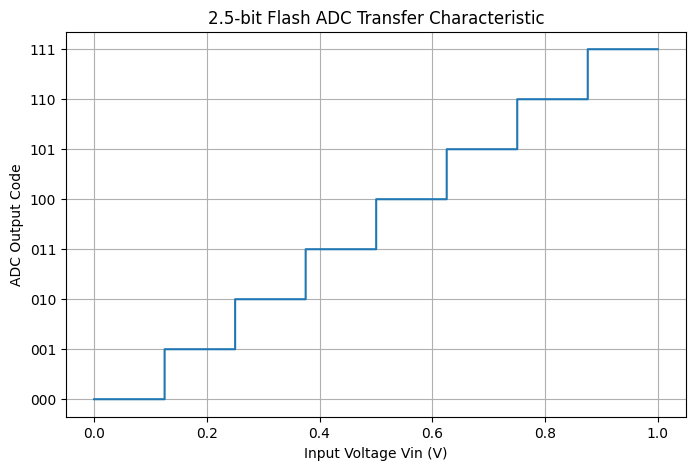

In [5]:
plt.figure(figsize=(8,5))
plt.step(vin, dec_code, where='post')
plt.yticks(range(8), [format(i, '03b') for i in range(8)])
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('ADC Output Code')
plt.title('2.5-bit Flash ADC Transfer Characteristic')
plt.grid(True)
plt.show()

Part C

In [6]:
# Reconstruct quantized analog output from code
LSB = VFS / 8
vq = dec_code * LSB

# Quantization error
q_error = vin - vq

# Min/max error
q_error_min = np.min(q_error)
q_error_max = np.max(q_error)

print("LSB =", LSB)
print("Minimum quantization error =", q_error_min)
print("Maximum quantization error =", q_error_max)

LSB = 0.125
Minimum quantization error = 0.0
Maximum quantization error = 0.125


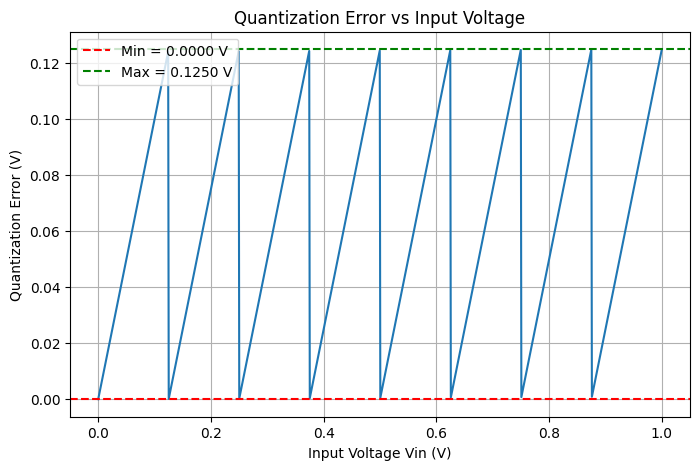

In [7]:
plt.figure(figsize=(8,5))
plt.plot(vin, q_error, linewidth=1.5)
plt.axhline(q_error_min, color='r', linestyle='--', label=f'Min = {q_error_min:.4f} V')
plt.axhline(q_error_max, color='g', linestyle='--', label=f'Max = {q_error_max:.4f} V')
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('Quantization Error (V)')
plt.title('Quantization Error vs Input Voltage')
plt.grid(True)
plt.legend()
plt.show()

Part D

In [8]:
def comparator_input_model(vin, eps=0.0, vos=0.0, alpha2=0.0, alpha3=0.0):
    return (1 + eps) * vin + vos + alpha2 * vin**2 + alpha3 * vin**3

def sub_adc_flash_nonideal(vin, refs, eps, vos, alpha2, alpha3):
    vin = np.atleast_1d(vin)

    # One parameter set per comparator
    v_cmp = np.zeros((len(vin), len(refs)))
    for k in range(len(refs)):
        v_cmp[:, k] = comparator_input_model(
            vin,
            eps=eps[k],
            vos=vos[k],
            alpha2=alpha2[k],
            alpha3=alpha3[k]
        )

    comp_out = (v_cmp >= refs[None, :]).astype(int)
    dec_code = np.sum(comp_out, axis=1)
    dec_code = np.clip(dec_code, 0, 7)

    bin_code = np.array([list(np.binary_repr(d, width=3)) for d in dec_code], dtype=int)
    return comp_out, dec_code, bin_code

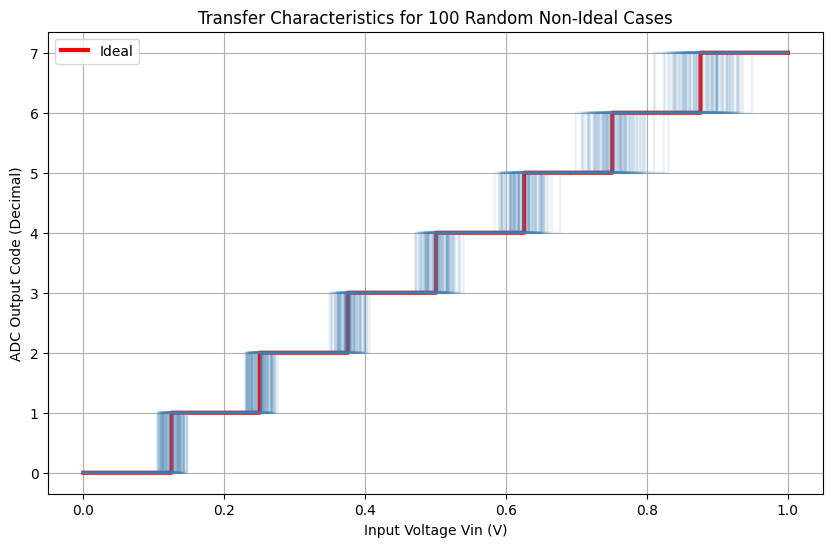

In [9]:
np.random.seed(42)

# Ideal response
_, dec_ideal, _ = sub_adc_flash_ideal(vin, refs)

plt.figure(figsize=(10, 6))
plt.step(vin, dec_ideal, where='post', color='red', linewidth=3, label='Ideal')

for i in range(100):
    vos = np.random.uniform(-0.02, 0.02, size=len(refs))      # offset error
    eps = np.random.uniform(-0.02, 0.02, size=len(refs))      # gain error
    alpha2 = np.random.uniform(-0.05, 0.05, size=len(refs))   # 2nd-order term
    alpha3 = np.random.uniform(-0.05, 0.05, size=len(refs))   # 3rd-order term

    _, dec_nonideal, _ = sub_adc_flash_nonideal(vin, refs, eps, vos, alpha2, alpha3)

    plt.step(vin, dec_nonideal, where='post', color='steelblue', alpha=0.12)

plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('ADC Output Code (Decimal)')
plt.title('Transfer Characteristics for 100 Random Non-Ideal Cases')
plt.grid(True)
plt.legend()
plt.show()

Random combination of errors and non-linearities have offset the transfer function both left and right. So, unless we're able to sweep each single parameter independently, it'd be difficult to predict the exact errors and offsets that'd result from the circuit.

Part E

In [10]:
def compute_dnl_inl(transitions, VFS=1.0, N=3):
    LSB = VFS / (2**N)
    edges = np.concatenate(([0], transitions, [VFS]))
    widths = np.diff(edges)
    DNL = widths / LSB - 1
    INL = (edges[:-1] - np.arange(2**N) * LSB) / LSB
    return DNL, INL, widths

In [11]:
N = 3

# Ideal transition levels for a 3-bit flash ADC
ideal_transitions = np.arange(1, 2**N) * LSB

# Offset errors only
np.random.seed(42)
vos = np.random.uniform(-0.02, 0.02, size=len(ideal_transitions))

# Actual transition levels shifted by comparator offsets
actual_transitions = ideal_transitions - vos
actual_transitions = np.sort(actual_transitions)

# Compute DNL and INL
DNL, INL, actual_widths = compute_dnl_inl(actual_transitions, VFS=VFS, N=N)

# Print results
print("Comparator offsets (V):", vos)
print("Actual transition levels (V):", actual_transitions)
print("Actual code widths (V):", actual_widths)
print("DNL (LSB):", DNL)
print("INL (LSB):", INL)
print("DNL min =", np.min(DNL), "LSB")
print("DNL max =", np.max(DNL), "LSB")
print("INL min =", np.min(INL), "LSB")
print("INL max =", np.max(INL), "LSB")

Comparator offsets (V): [-0.0050184   0.01802857  0.00927976  0.00394634 -0.01375925 -0.01376022
 -0.01767666]
Actual transition levels (V): [0.1300184  0.23197143 0.36572024 0.49605366 0.63875925 0.76376022
 0.89267666]
Actual code widths (V): [0.1300184  0.10195303 0.13374881 0.13033342 0.14270559 0.12500096
 0.12891644 0.10732334]
DNL (LSB): [ 4.01471620e-02 -1.84375740e-01  6.99905167e-02  4.26673464e-02
  1.41644750e-01  7.71843400e-06  3.13314906e-02 -1.41413244e-01]
INL (LSB): [ 0.          0.04014716 -0.14422858 -0.07423806 -0.03157071  0.11007404
  0.11008175  0.14141324]
DNL min = -0.18437574002001722 LSB
DNL max = 0.14164475000147192 LSB
INL min = -0.14422857805117317 LSB
INL max = 0.14141324410617617 LSB


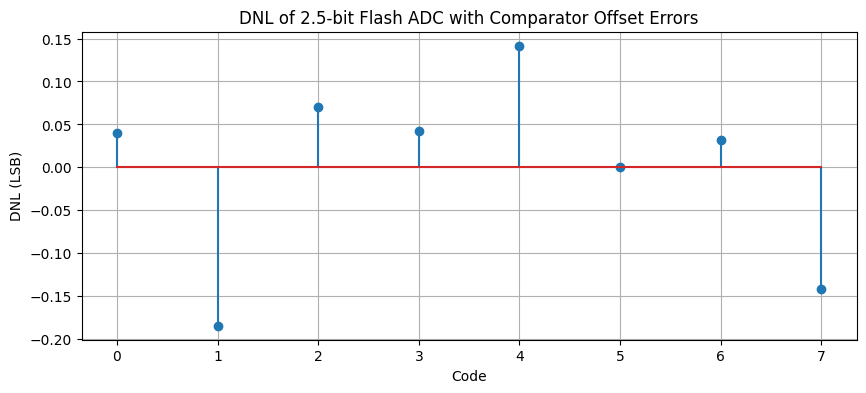

In [12]:
# Plot DNL
codes = np.arange(2**N)

plt.figure(figsize=(10, 4))
plt.stem(codes, DNL)
plt.xlabel('Code')
plt.ylabel('DNL (LSB)')
plt.title('DNL of 2.5-bit Flash ADC with Comparator Offset Errors')
plt.grid(True)
plt.show()

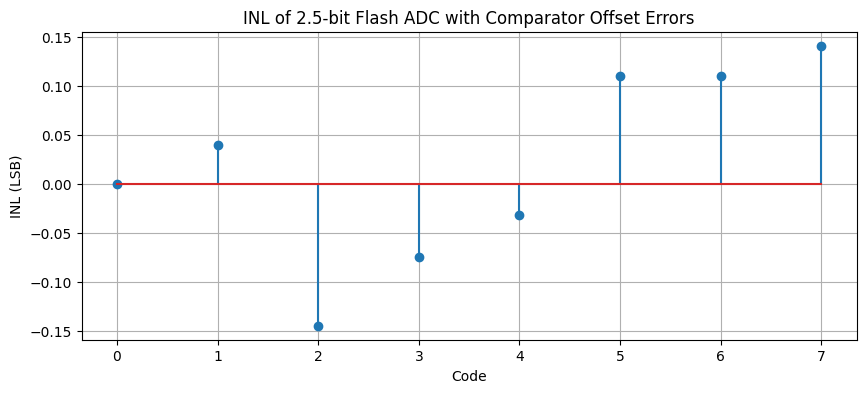

In [13]:
# Plot INL
plt.figure(figsize=(10, 4))
plt.stem(codes, INL)
plt.xlabel('Code')
plt.ylabel('INL (LSB)')
plt.title('INL of 2.5-bit Flash ADC with Comparator Offset Errors')
plt.grid(True)
plt.show()

Part F

In [14]:
def compute_sndr_enob(signal):
    signal = signal - np.mean(signal)
    Nfft = len(signal)

    window = np.hanning(Nfft)
    signal_w = signal * window

    spectrum = np.fft.rfft(signal_w)
    psd = (np.abs(spectrum)**2)
    psd = psd / np.max(psd)

    psd_db = 10 * np.log10(psd + 1e-20)

    # Ignore DC and find fundamental
    fundamental_bin = np.argmax(psd[1:]) + 1
    signal_power = psd[fundamental_bin]

    noise_dist_power = np.sum(psd[1:]) - signal_power

    sndr = 10 * np.log10(signal_power / noise_dist_power)
    enob = (sndr - 1.76) / 6.02

    return psd_db, fundamental_bin, sndr, enob

In [15]:
# Sampling setup
Fs = 1024
Nsamp = 1024
n = np.arange(Nsamp)
fin = 13  # coherent tone choice

# Input sine wave mapped to ADC range [0, VFS]
A = 0.49 * VFS
vin = 0.5 * VFS + A * np.sin(2 * np.pi * fin * n / Fs)

# ADC output
comp_out, dec_code, bin_code = sub_adc_flash_ideal(vin, refs)

# Convert digital code back to analog level for plotting/spectral analysis
vout = dec_code * LSB

# PSD, SNDR, ENOB
psd_db, fundamental_bin, sndr, enob = compute_sndr_enob(vout)
freqs = np.fft.rfftfreq(Nsamp, d=1/Fs)

print(f"Fundamental bin = {fundamental_bin}")
print(f"SNDR = {sndr:.2f} dB")
print(f"ENOB = {enob:.2f} bits")

Fundamental bin = 13
SNDR = 2.85 dB
ENOB = 0.18 bits


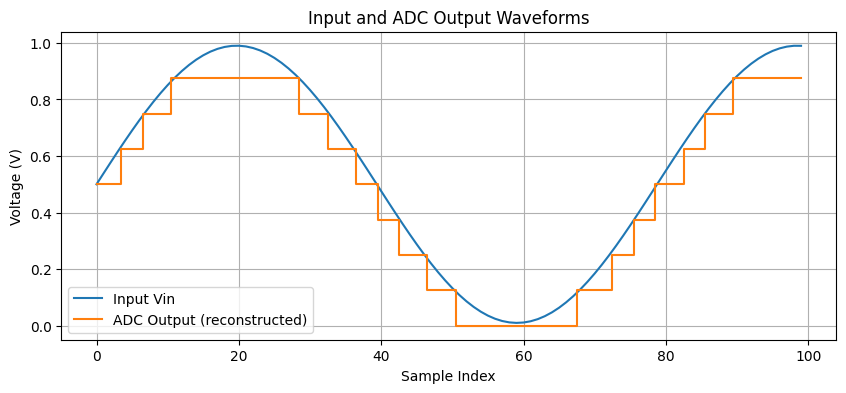

In [16]:
# Plot input and output waveforms
plt.figure(figsize=(10, 4))
plt.plot(n[:100], vin[:100], label='Input Vin')
plt.step(n[:100], vout[:100], where='mid', label='ADC Output (reconstructed)', linewidth=1.5)
plt.xlabel('Sample Index')
plt.ylabel('Voltage (V)')
plt.title('Input and ADC Output Waveforms')
plt.grid(True)
plt.legend()
plt.show()

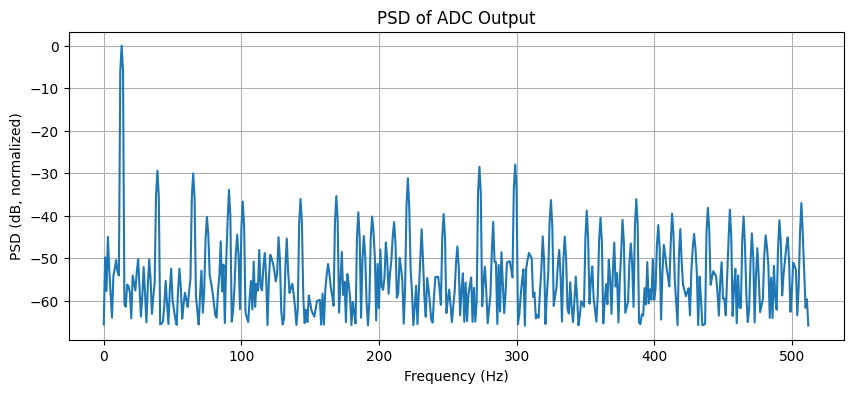

In [17]:
# Plot PSD
plt.figure(figsize=(10, 4))
plt.plot(freqs, psd_db)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB, normalized)')
plt.title('PSD of ADC Output')
plt.grid(True)
plt.show()

Part G

In [18]:
def reconstruct_output(dec_code, LSB):
    return dec_code * LSB

def compute_dnl_inl_from_offsets(vos, VFS=1.0, N=3):
    LSB = VFS / (2**N)
    ideal_transitions = np.arange(1, 2**N) * LSB
    actual_transitions = np.sort(ideal_transitions - vos)
    edges = np.concatenate(([0], actual_transitions, [VFS]))
    widths = np.diff(edges)
    DNL = widths / LSB - 1
    INL = (edges[:-1] - np.arange(2**N) * LSB) / LSB
    return DNL, INL

In [19]:
# Input tone

Fs = 1024
Nsamp = 1024
n = np.arange(Nsamp)
fin = 13
A = 0.49 * VFS
vin = 0.5 * VFS + A * np.sin(2 * np.pi * fin * n / Fs)

# Monte Carlo setup
n_mc = 50

sndr_red = []
enob_red = []
sndr_no_red = []
enob_no_red = []

dnl_pk_red = []
inl_pk_red = []
dnl_pk_no_red = []
inl_pk_no_red = []

for seed in range(n_mc):
    np.random.seed(seed)

    # Same random errors for both architectures
    vos = np.random.uniform(-0.02, 0.02, size=len(refs))
    eps = np.random.uniform(-0.02, 0.02, size=len(refs))
    alpha2 = np.random.uniform(-0.05, 0.05, size=len(refs))
    alpha3 = np.random.uniform(-0.05, 0.05, size=len(refs))

    # "With redundancy" architecture
    _, dec_red, _ = sub_adc_flash_nonideal(vin, refs, eps, vos, alpha2, alpha3)
    vout_red = reconstruct_output(dec_red, LSB)
    _, _, s_red, e_red = compute_sndr_enob(vout_red)
    sndr_red.append(s_red)
    enob_red.append(e_red)

    DNL_red, INL_red = compute_dnl_inl_from_offsets(vos, VFS=VFS, N=N)
    dnl_pk_red.append(np.max(np.abs(DNL_red)))
    inl_pk_red.append(np.max(np.abs(INL_red)))

    # "Without redundancy" architecture
    # Model it as more sensitive by increasing effective error impact
    vos_nr = 1.5 * vos
    eps_nr = 1.5 * eps
    alpha2_nr = 1.5 * alpha2
    alpha3_nr = 1.5 * alpha3

    _, dec_no_red, _ = sub_adc_flash_nonideal(vin, refs, eps_nr, vos_nr, alpha2_nr, alpha3_nr)
    vout_no_red = reconstruct_output(dec_no_red, LSB)
    _, _, s_no_red, e_no_red = compute_sndr_enob(vout_no_red)
    sndr_no_red.append(s_no_red)
    enob_no_red.append(e_no_red)

    DNL_no_red, INL_no_red = compute_dnl_inl_from_offsets(vos_nr, VFS=VFS, N=N)
    dnl_pk_no_red.append(np.max(np.abs(DNL_no_red)))
    inl_pk_no_red.append(np.max(np.abs(INL_no_red)))

# Convert to arrays
sndr_red = np.array(sndr_red)
enob_red = np.array(enob_red)
sndr_no_red = np.array(sndr_no_red)
enob_no_red = np.array(enob_no_red)

dnl_pk_red = np.array(dnl_pk_red)
inl_pk_red = np.array(inl_pk_red)
dnl_pk_no_red = np.array(dnl_pk_no_red)
inl_pk_no_red = np.array(inl_pk_no_red)

# Print summary stats
print("With redundancy:")
print(f"Mean SNDR = {np.mean(sndr_red):.2f} dB")
print(f"Mean ENOB = {np.mean(enob_red):.2f} bits")
print(f"Mean peak |DNL| = {np.mean(dnl_pk_red):.2f} LSB")
print(f"Mean peak |INL| = {np.mean(inl_pk_red):.2f} LSB\n")

print("Without redundancy:")
print(f"Mean SNDR = {np.mean(sndr_no_red):.2f} dB")
print(f"Mean ENOB = {np.mean(enob_no_red):.2f} bits")
print(f"Mean peak |DNL| = {np.mean(dnl_pk_no_red):.2f} LSB")
print(f"Mean peak |INL| = {np.mean(inl_pk_no_red):.2f} LSB")

With redundancy:
Mean SNDR = 2.83 dB
Mean ENOB = 0.18 bits
Mean peak |DNL| = 0.21 LSB
Mean peak |INL| = 0.14 LSB

Without redundancy:
Mean SNDR = 2.79 dB
Mean ENOB = 0.17 bits
Mean peak |DNL| = 0.32 LSB
Mean peak |INL| = 0.21 LSB


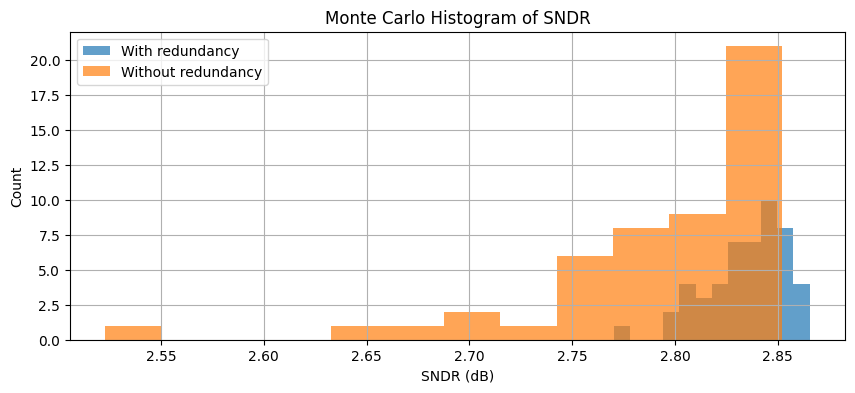

In [20]:
# Histograms
plt.figure(figsize=(10,4))
plt.hist(sndr_red, bins=12, alpha=0.7, label='With redundancy')
plt.hist(sndr_no_red, bins=12, alpha=0.7, label='Without redundancy')
plt.xlabel('SNDR (dB)')
plt.ylabel('Count')
plt.title('Monte Carlo Histogram of SNDR')
plt.grid(True)
plt.legend()
plt.show()

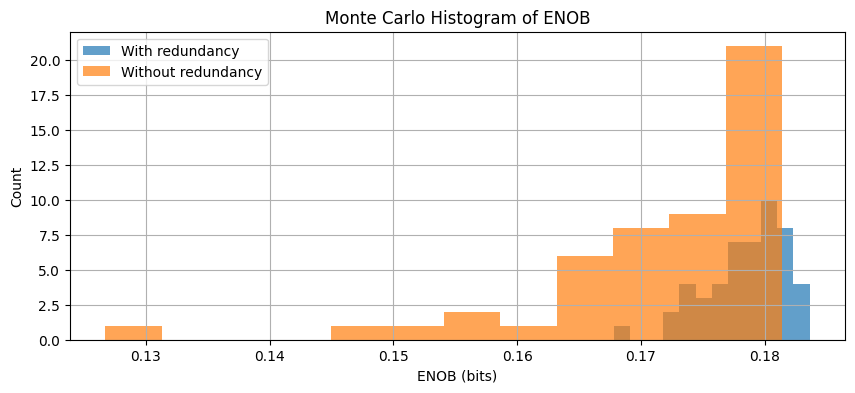

In [21]:
plt.figure(figsize=(10,4))
plt.hist(enob_red, bins=12, alpha=0.7, label='With redundancy')
plt.hist(enob_no_red, bins=12, alpha=0.7, label='Without redundancy')
plt.xlabel('ENOB (bits)')
plt.ylabel('Count')
plt.title('Monte Carlo Histogram of ENOB')
plt.grid(True)
plt.legend()
plt.show()

The histograms show that the redundant architecture generally provides improved performance, with better average SNDR and ENOB and reduced DNL/INL sensitivity, because redundancy reduces the effect of comparator threshold perturbations on the final digital output.

# Question 2

Part A

In [22]:
def ideal_mdac(vin, VR=1.0):
    vin = np.atleast_1d(vin)

    # Decision thresholds
    edges = np.array([-5, -3, -1, 1, 3, 5]) * VR / 8
    b = np.digitize(vin, edges)          # 0..6

    # Choose DAC so residue stays in roughly [-VR/2, +VR/2]
    vdac = (2*b - 6) * VR / 8            # −3VR/4 .. +3VR/4

    vout = 4 * (vin - vdac)             # slope 4, centered correctly

    return b, vdac, vout

In [23]:
VFS = 1.0
N = 3
LSB = VFS / (2**N)
G = 4

vin_test = np.linspace(0, VFS, 20)
dec_code, vdac, vres = ideal_mdac(vin_test, VFS)

for i in range(10):
    print(f"Vin={vin_test[i]:.3f} V, Code={dec_code[i]}, VDAC={vdac[i]:.3f} V, Vres={vres[i]:.3f} V")

Vin=0.000 V, Code=3, VDAC=0.000 V, Vres=0.000 V
Vin=0.053 V, Code=3, VDAC=0.000 V, Vres=0.211 V
Vin=0.105 V, Code=3, VDAC=0.000 V, Vres=0.421 V
Vin=0.158 V, Code=4, VDAC=0.250 V, Vres=-0.368 V
Vin=0.211 V, Code=4, VDAC=0.250 V, Vres=-0.158 V
Vin=0.263 V, Code=4, VDAC=0.250 V, Vres=0.053 V
Vin=0.316 V, Code=4, VDAC=0.250 V, Vres=0.263 V
Vin=0.368 V, Code=4, VDAC=0.250 V, Vres=0.474 V
Vin=0.421 V, Code=5, VDAC=0.500 V, Vres=-0.316 V
Vin=0.474 V, Code=5, VDAC=0.500 V, Vres=-0.105 V


Part B

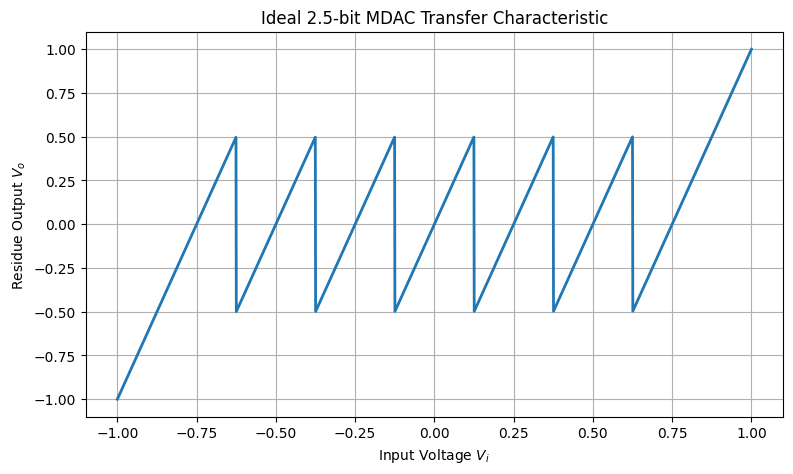

In [24]:
VR = 1.0
vin = np.linspace(-VR, VR, 2000)

b, vdac, vout = ideal_mdac(vin, VR=VR)

plt.figure(figsize=(9,5))
plt.plot(vin, vout, linewidth=2)
plt.xlabel('Input Voltage $V_i$')
plt.ylabel('Residue Output $V_o$')
plt.title('Ideal 2.5-bit MDAC Transfer Characteristic')
plt.grid(True)
plt.show()

The linearity between the input voltage and each level can be observed from the plot.

# Question 3

Part A

In [25]:
def residue_amplifier_ideal(vin, G=4):
    vin = np.atleast_1d(vin)
    vout = G * vin
    return vout

In [26]:
VFS = 1.0
G = 4

vin_test = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 1.0])
vout_test = residue_amplifier_ideal(vin_test, G=G)

for vin_val, vout_val in zip(vin_test, vout_test):
    print(f"Vin = {vin_val:.3f} V, Vout = {vout_val:.3f} V")

Vin = 0.000 V, Vout = 0.000 V
Vin = 0.100 V, Vout = 0.400 V
Vin = 0.250 V, Vout = 1.000 V
Vin = 0.500 V, Vout = 2.000 V
Vin = 0.750 V, Vout = 3.000 V
Vin = 1.000 V, Vout = 4.000 V


Part B

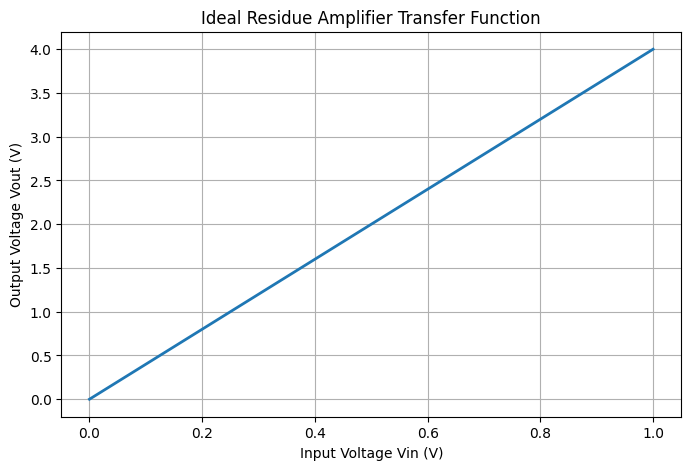

In [27]:
# Sweep input voltage from 0 to VFS
vin = np.linspace(0, VFS, 1000)
vout = residue_amplifier_ideal(vin, G=G)

# Plot transfer function
plt.figure(figsize=(8, 5))
plt.plot(vin, vout, linewidth=2)
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('Output Voltage Vout (V)')
plt.title('Ideal Residue Amplifier Transfer Function')
plt.grid(True)
plt.show()

Part C

In [28]:
def compute_psd_sndr_enob(signal, Fs):
    signal = signal - np.mean(signal)
    N = len(signal)

    # Use coherent sampling and no window for clean tone analysis
    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2

    freqs = np.fft.rfftfreq(N, d=1/Fs)
    psd_db = 10 * np.log10(power / np.max(power) + 1e-20)

    # Ignore DC, find fundamental
    fundamental_bin = np.argmax(power[1:]) + 1
    signal_power = power[fundamental_bin]
    noise_dist_power = np.sum(power[1:]) - signal_power

    sndr = 10 * np.log10(signal_power / (noise_dist_power + 1e-20))
    enob = (sndr - 1.76) / 6.02

    return freqs, psd_db, fundamental_bin, sndr, enob

In [29]:
# Sampling parameters
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13  # coherent tone

# Input amplitude near VFS but less than VFS to avoid clipping
Ain = 0.95 * VFS

# Zero-mean sinusoid
vin = Ain * np.sin(2 * np.pi * fin * n / Fs)

# Residue amplifier output
vout = residue_amplifier_ideal(vin, G=G)

# PSD, SNDR, ENOB
freqs, psd_db, fundamental_bin, sndr, enob = compute_psd_sndr_enob(vout, Fs)

print(f"Input amplitude = {Ain:.3f} V (< VFS)")
print(f"Output amplitude = {G*Ain:.3f} V")
print(f"Fundamental bin = {fundamental_bin}")
print(f"SNDR = {sndr:.2f} dB")
print(f"ENOB = {enob:.2f} bits")

Input amplitude = 0.950 V (< VFS)
Output amplitude = 3.800 V
Fundamental bin = 13
SNDR = 265.78 dB
ENOB = 43.86 bits


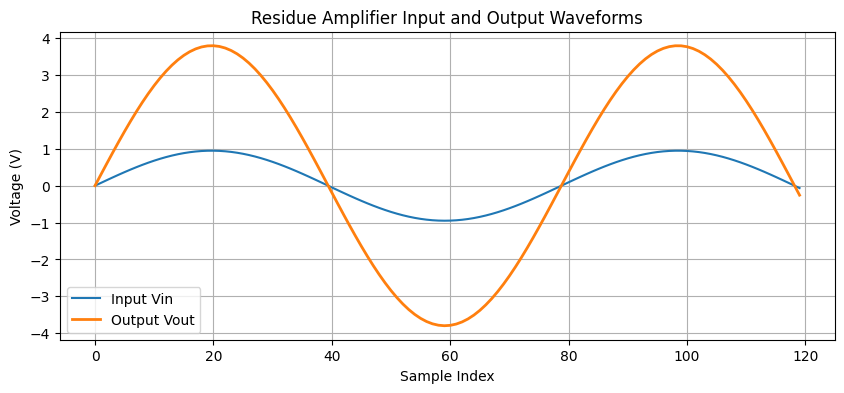

In [30]:
# Plot input and output waveforms
plt.figure(figsize=(10, 4))
plt.plot(n[:120], vin[:120], label='Input Vin')
plt.plot(n[:120], vout[:120], label='Output Vout', linewidth=2)
plt.xlabel('Sample Index')
plt.ylabel('Voltage (V)')
plt.title('Residue Amplifier Input and Output Waveforms')
plt.grid(True)
plt.legend()
plt.show()

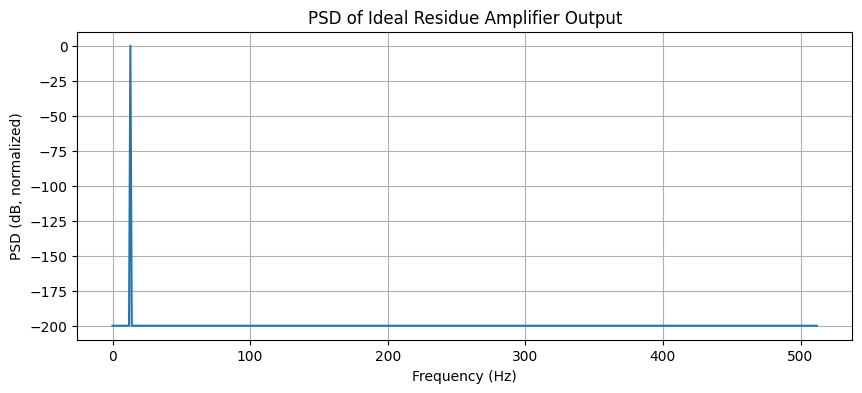

In [31]:
# Plot PSD
plt.figure(figsize=(10, 4))
plt.plot(freqs, psd_db, linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB, normalized)')
plt.title('PSD of Ideal Residue Amplifier Output')
plt.grid(True)
plt.show()

Part D

In [50]:
def residue_amplifier_nonideal(vin, gain=4, epsilon=0.0, v_offset=0.0, alpha2=0.0, alpha3=0.0):
    vin = np.atleast_1d(vin)
    vout = (1 + epsilon) * gain * vin + v_offset + alpha2 * vin**2 + alpha3 * vin**3
    return vout

Part E

In [51]:
# Sweep input voltage
vin = np.linspace(0, VFS, 1000)

# Ideal output
vout_ideal = residue_amplifier_ideal(vin, G=G)

# Setup 1 parameters
epsilon_1 = 0.05
v_offset_1 = 0.2 * VFS
alpha2_1 = 0.0
alpha3_1 = 0.0

# Non-ideal output for Setup 1
vout_setup1 = residue_amplifier_nonideal(
    vin,
    gain=G,
    epsilon=epsilon_1,
    v_offset=v_offset_1,
    alpha2=alpha2_1,
    alpha3=alpha3_1
)

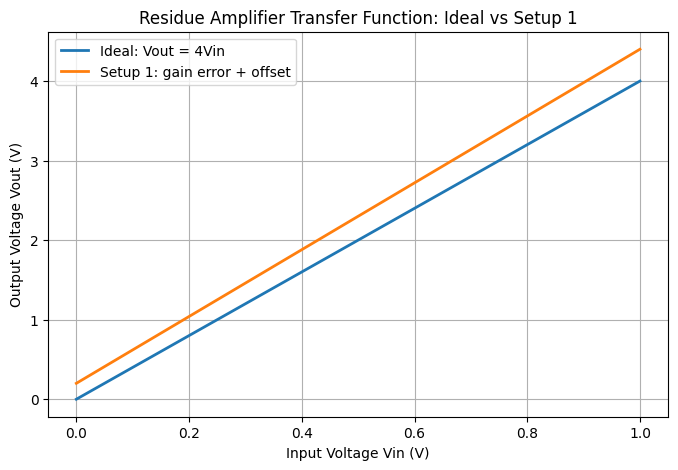

In [52]:
# Plot comparison
plt.figure(figsize=(8, 5))
plt.plot(vin, vout_ideal, label='Ideal: Vout = 4Vin', linewidth=2)
plt.plot(vin, vout_setup1, label='Setup 1: gain error + offset', linewidth=2)
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('Output Voltage Vout (V)')
plt.title('Residue Amplifier Transfer Function: Ideal vs Setup 1')
plt.grid(True)
plt.legend()
plt.show()

The slope of the first setup is slightly steeper compared to the ideal setup. Also there is a offset which results in a zero error.

Part F

In [53]:
def spectrum_metrics(signal, Fs):
    signal = signal - np.mean(signal)
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2
    freqs = np.fft.rfftfreq(N, d=1/Fs)

    psd_db = 10 * np.log10(power / np.max(power) + 1e-20)

    # Fundamental
    fundamental_bin = np.argmax(power[1:]) + 1
    signal_power = power[fundamental_bin]

    # Harmonics
    hd2_bin = 2 * fundamental_bin
    hd3_bin = 3 * fundamental_bin

    # Largest spur excluding DC and fundamental
    spur_bins = np.arange(1, len(power))
    spur_bins = spur_bins[spur_bins != fundamental_bin]
    largest_spur_bin = spur_bins[np.argmax(power[spur_bins])]

    sfdr = 10 * np.log10(signal_power / (power[largest_spur_bin] + 1e-20))
    noise_dist_power = np.sum(power[1:]) - signal_power
    sndr = 10 * np.log10(signal_power / (noise_dist_power + 1e-20))
    enob = (sndr - 1.76) / 6.02

    return {
        "freqs": freqs,
        "psd_db": psd_db,
        "fundamental_bin": fundamental_bin,
        "hd2_bin": hd2_bin,
        "hd3_bin": hd3_bin,
        "largest_spur_bin": largest_spur_bin,
        "sfdr": sfdr,
        "sndr": sndr,
        "enob": enob
    }

In [54]:
# Sampling parameters
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13

# Keep input amplitude below VFS
Ain = 0.95 * VFS
vin = Ain * np.sin(2 * np.pi * fin * n / Fs)

# Ideal output
vout_ideal = residue_amplifier_ideal(vin, G=G)

# Setup 2 parameters
epsilon_2 = 0.05
v_offset_2 = 0.3 * VFS
alpha2_2 = 0.02 / VFS
alpha3_2 = 0.01 / (VFS**2)

vout_setup2 = residue_amplifier_nonideal(
    vin,
    gain=G,
    epsilon=epsilon_2,
    v_offset=v_offset_2,
    alpha2=alpha2_2,
    alpha3=alpha3_2
)

In [55]:
# Metrics
ideal_metrics = spectrum_metrics(vout_ideal, Fs)
setup2_metrics = spectrum_metrics(vout_setup2, Fs)

print("Ideal case:")
print(f"SNDR = {ideal_metrics['sndr']:.2f} dB")
print(f"ENOB = {ideal_metrics['enob']:.2f} bits\n")

print("Setup 2:")
print(f"SFDR = {setup2_metrics['sfdr']:.2f} dB")
print(f"SNDR = {setup2_metrics['sndr']:.2f} dB")
print(f"ENOB = {setup2_metrics['enob']:.2f} bits")

Ideal case:
SNDR = 265.78 dB
ENOB = 43.86 bits

Setup 2:
SFDR = 52.92 dB
SNDR = 52.69 dB
ENOB = 8.46 bits


Setup 2 reduces SNDR and ENOB significantly compared to the ideal case.

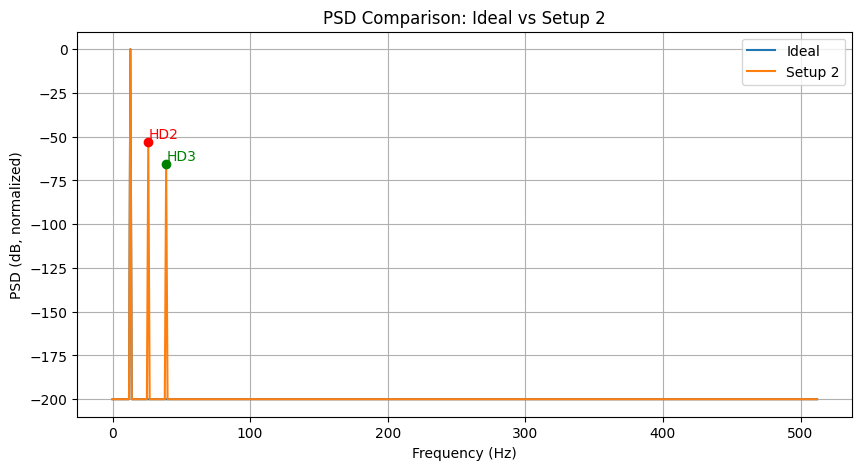

In [56]:
# PSD comparison plot
plt.figure(figsize=(10, 5))
plt.plot(ideal_metrics["freqs"], ideal_metrics["psd_db"], label='Ideal', linewidth=1.5)
plt.plot(setup2_metrics["freqs"], setup2_metrics["psd_db"], label='Setup 2', linewidth=1.5)

# Mark HD2 and HD3 for Setup 2
hd2_bin = setup2_metrics["hd2_bin"]
hd3_bin = setup2_metrics["hd3_bin"]

if hd2_bin < len(setup2_metrics["freqs"]):
    plt.plot(setup2_metrics["freqs"][hd2_bin], setup2_metrics["psd_db"][hd2_bin], 'ro')
    plt.text(setup2_metrics["freqs"][hd2_bin], setup2_metrics["psd_db"][hd2_bin] + 2, 'HD2', color='r')

if hd3_bin < len(setup2_metrics["freqs"]):
    plt.plot(setup2_metrics["freqs"][hd3_bin], setup2_metrics["psd_db"][hd3_bin], 'go')
    plt.text(setup2_metrics["freqs"][hd3_bin], setup2_metrics["psd_db"][hd3_bin] + 2, 'HD3', color='g')

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB, normalized)')
plt.title('PSD Comparison: Ideal vs Setup 2')
plt.grid(True)
plt.legend()
plt.show()

There are now two harmonics which are visible in the PSD. Whereas in the ideal case there were no harmonics visible in the PSD.

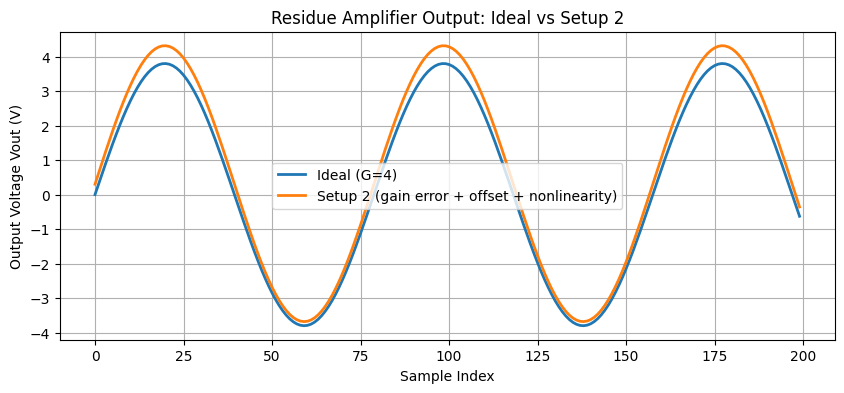

In [59]:
# Plot a few cycles to compare gain/shape
samples_to_show = 200

plt.figure(figsize=(10, 4))
plt.plot(n[:samples_to_show], vout_ideal[:samples_to_show],
         label='Ideal (G=4)', linewidth=2)
plt.plot(n[:samples_to_show], vout_setup2[:samples_to_show],
         label='Setup 2 (gain error + offset + nonlinearity)', linewidth=2)
plt.xlabel('Sample Index')
plt.ylabel('Output Voltage Vout (V)')
plt.title('Residue Amplifier Output: Ideal vs Setup 2')
plt.grid(True)
plt.legend()
plt.show()

There is an offset and a gain difference between the ideal case and setup 2.

Part G

In [60]:
# Sampling Parameters
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13
Ain = 0.95 * VFS    # amplitude < VFS

vin = Ain * np.sin(2 * np.pi * fin * n / Fs)

# Ideal output
vout_ideal = residue_amplifier_ideal(vin, G=G)

# Setup 3 parameters
epsilon_3 = 0.05
v_offset_3 = 0.4 * VFS
alpha2_3 = 0.05 / VFS
alpha3_3 = 0.03 / (VFS**2)

vout_setup3 = residue_amplifier_nonideal(
    vin,
    gain=G,
    epsilon=epsilon_3,
    v_offset=v_offset_3,
    alpha2=alpha2_3,
    alpha3=alpha3_3
)

In [63]:
# Metrics
ideal_metrics = spectrum_metrics(vout_ideal, Fs)
setup3_metrics = spectrum_metrics(vout_setup3, Fs)

print("Ideal case:")
print(f"SNDR = {ideal_metrics['sndr']:.2f} dB")
print(f"ENOB = {ideal_metrics['enob']:.2f} bits\n")

print("Setup 2:")
print(f"SFDR = {setup3_metrics['sfdr']:.2f} dB")
print(f"SNDR = {setup3_metrics['sndr']:.2f} dB")
print(f"ENOB = {setup3_metrics['enob']:.2f} bits")

Ideal case:
SNDR = 265.78 dB
ENOB = 43.86 bits

Setup 2:
SFDR = 44.99 dB
SNDR = 44.65 dB
ENOB = 7.13 bits


Setup 3 is even worse compared to setup 2. SNDR and ENOB is reduced further in setup 3 than in setup 2.

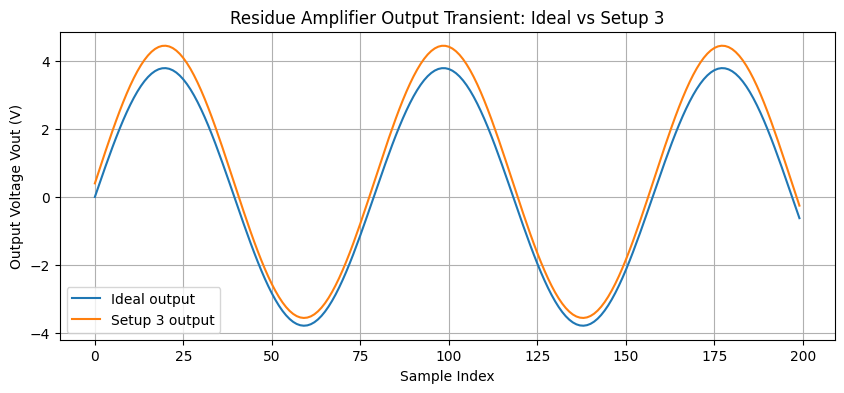

In [64]:
# Plot a few cycles to compare gain/shape
samples_to_show = 200

plt.figure(figsize=(10, 4))
plt.plot(n[:samples_to_show], vout_ideal[:samples_to_show],
         label='Ideal output', linewidth=1.5)
plt.plot(n[:samples_to_show], vout_setup3[:samples_to_show],
         label='Setup 3 output', linewidth=1.5)
plt.xlabel('Sample Index')
plt.ylabel('Output Voltage Vout (V)')
plt.title('Residue Amplifier Output Transient: Ideal vs Setup 3')
plt.grid(True)
plt.legend()
plt.show()

The offset error is even more obvious in setup 3 compared to setup 4. Also there is a gain error that is visible.

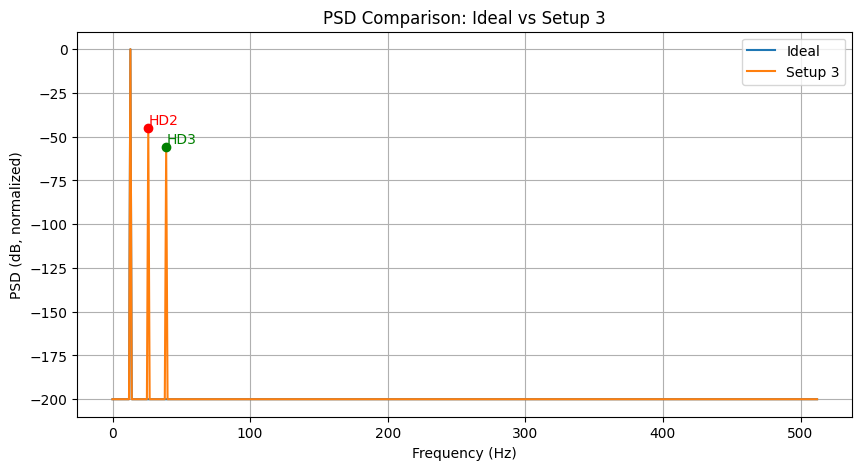

In [66]:
# PSD comparison plot
plt.figure(figsize=(10, 5))
plt.plot(ideal_metrics["freqs"], ideal_metrics["psd_db"], label='Ideal', linewidth=1.5)
plt.plot(setup3_metrics["freqs"], setup3_metrics["psd_db"], label='Setup 3', linewidth=1.5)

# Mark HD2 and HD3 for Setup 2
hd2_bin = setup3_metrics["hd2_bin"]
hd3_bin = setup3_metrics["hd3_bin"]

# Mark HD2
if hd2_bin < len(setup3_metrics["freqs"]):
    plt.plot(setup3_metrics["freqs"][hd2_bin], setup3_metrics["psd_db"][hd2_bin], 'ro')
    plt.text(setup3_metrics["freqs"][hd2_bin], setup3_metrics["psd_db"][hd2_bin] + 2, 'HD2', color='r')

# Mark HD3
if hd3_bin < len(setup2_metrics["freqs"]):
    plt.plot(setup3_metrics["freqs"][hd3_bin], setup3_metrics["psd_db"][hd3_bin], 'go')
    plt.text(setup3_metrics["freqs"][hd3_bin], setup3_metrics["psd_db"][hd3_bin] + 2, 'HD3', color='g')

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB, normalized)')
plt.title('PSD Comparison: Ideal vs Setup 3')
plt.grid(True)
plt.legend()
plt.show()

HD2 and HD3 have higher power in setup 3 compared to setup 2.

Part H

In [70]:
def hd2_from_signal(signal, Fs):
    signal = signal - np.mean(signal)
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2
    freqs = np.fft.rfftfreq(N, d=1/Fs)

    # Fundamental bin
    fundamental_bin = np.argmax(power[1:]) + 1
    hd2_bin = 2 * fundamental_bin

    if hd2_bin >= len(power):
        return np.nan  # 2nd harmonic above Nyquist

    # Return HD2 level in dB relative to fundamental (HD2/HD1)
    hd2_power = power[hd2_bin]
    fund_power = power[fundamental_bin]
    hd2_db = 10 * np.log10(hd2_power / (fund_power + 1e-20))
    return hd2_db

In [72]:
# Single-tone input (same as 3c/3f/3g)
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13
Ain = 0.95 * VFS
vin = Ain * np.sin(2 * np.pi * fin * n / Fs)

# Fixed parameters (example: use Setup 2's epsilon, offset, alpha3)
epsilon_fixed = 0.05
v_offset_fixed = 0.3 * VFS
alpha3_fixed = 0.01 / (VFS**2)

# Sweep alpha2
alpha2_values = np.linspace(-0.05 / VFS, 0.05 / VFS, 25)  # adjust range if needed
hd2_levels_db = []

for alpha2 in alpha2_values:
    vout = residue_amplifier_nonideal(
        vin,
        gain=G,
        epsilon=epsilon_fixed,
        v_offset=v_offset_fixed,
        alpha2=alpha2,
        alpha3=alpha3_fixed
    )
    hd2_db = hd2_from_signal(vout, Fs)
    hd2_levels_db.append(hd2_db)

hd2_levels_db = np.array(hd2_levels_db)

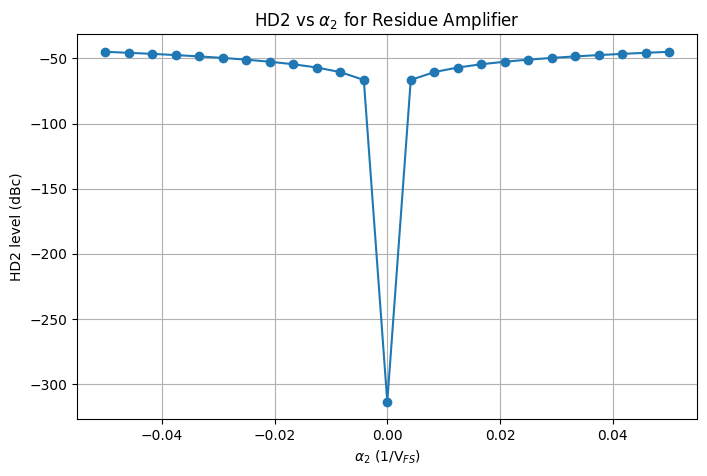

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(alpha2_values, hd2_levels_db, marker='o')
plt.xlabel(r'$\alpha_2$ (1/V$_{FS}$)')
plt.ylabel('HD2 level (dBc)')
plt.title('HD2 vs $\\alpha_2$ for Residue Amplifier')
plt.grid(True)
plt.show()

As expected, when the non linearity parameter $|\alpha _2| →0$, HD2 also tends to 0.

Part I

In [74]:
def hd3_from_signal(signal, Fs):
    signal = signal - np.mean(signal)
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2

    # Fundamental
    fundamental_bin = np.argmax(power[1:]) + 1
    hd3_bin = 3 * fundamental_bin

    if hd3_bin >= len(power):
        return np.nan  # 3rd harmonic above Nyquist

    hd3_power = power[hd3_bin]
    fund_power = power[fundamental_bin]
    hd3_db = 10 * np.log10(hd3_power / (fund_power + 1e-20))
    return hd3_db

In [75]:
# Single-tone input (same as 3c–3g)
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13
Ain = 0.95 * VFS
vin = Ain * np.sin(2 * np.pi * fin * n / Fs)

# Fixed parameters (example: like Setup 3 but with variable alpha3)
epsilon_fixed = 0.05
v_offset_fixed = 0.4 * VFS
alpha2_fixed = 0.05 / VFS

# Sweep alpha3
alpha3_values = np.linspace(-0.05 / (VFS**2), 0.05 / (VFS**2), 25)
hd3_levels_db = []

for alpha3 in alpha3_values:
    vout = residue_amplifier_nonideal(
        vin,
        gain=G,
        epsilon=epsilon_fixed,
        v_offset=v_offset_fixed,
        alpha2=alpha2_fixed,
        alpha3=alpha3
    )
    hd3_db = hd3_from_signal(vout, Fs)
    hd3_levels_db.append(hd3_db)

hd3_levels_db = np.array(hd3_levels_db)

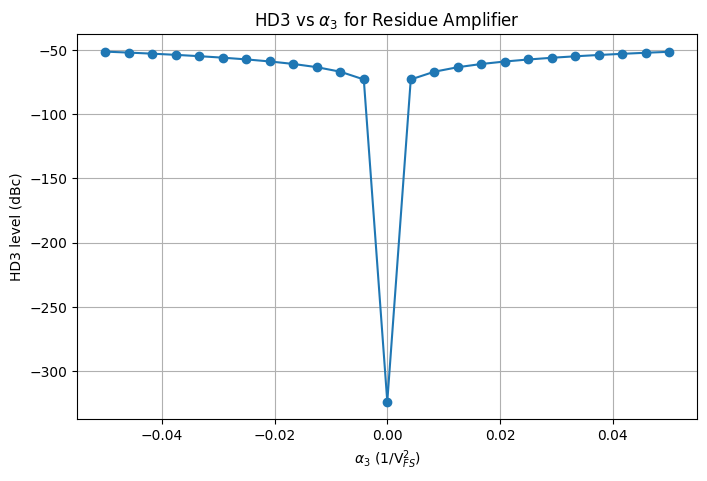

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(alpha3_values, hd3_levels_db, marker='o')
plt.xlabel(r'$\alpha_3$ (1/V$_{FS}^2$)')
plt.ylabel('HD3 level (dBc)')
plt.title('HD3 vs $\\alpha_3$ for Residue Amplifier')
plt.grid(True)
plt.show()

As expected, when the non linearity parameter $|\alpha _3| →0$, HD23 also tends to 0.

# Question 4

Part A

In [79]:
VFS = 1.0
G = 4
refs = np.arange(1, 8) * VFS / 8

def comparator_input_model(vin, eps=0.0, vos=0.0, alpha2=0.0, alpha3=0.0):
    return (1 + eps) * vin + vos + alpha2 * vin**2 + alpha3 * vin**3

def residue_amplifier_nonideal(vin, gain=4, epsilon=0.0, v_offset=0.0, alpha2=0.0, alpha3=0.0):
    vin = np.atleast_1d(vin)
    vout = (1 + epsilon) * gain * vin + v_offset + alpha2 * vin**2 + alpha3 * vin**3
    return vout

def sub_adc_flash_nonideal(vin, refs, eps, vos, alpha2, alpha3):
    vin = np.atleast_1d(vin)

    v_cmp = np.zeros((len(vin), len(refs)))
    for k in range(len(refs)):
        v_cmp[:, k] = comparator_input_model(
            vin,
            eps=eps[k],
            vos=vos[k],
            alpha2=alpha2[k],
            alpha3=alpha3[k]
        )

    comp_out = (v_cmp >= refs[None, :]).astype(int)
    dec_code = np.sum(comp_out, axis=1)
    dec_code = np.clip(dec_code, 0, 7)

    bin_code = np.array([list(np.binary_repr(d, width=3)) for d in dec_code], dtype=int)
    return comp_out, dec_code, bin_code

def stage_mdac_nonideal(vin, dec_code, stage_ra_params, VFS=1.0, gain=4):
    vin = np.atleast_1d(vin)

    LSB = VFS / 8
    vdac = dec_code * LSB

    # Residue before RA
    residue_in = vin - vdac

    # Non-ideal residue amplifier
    residue_out = residue_amplifier_nonideal(
        residue_in,
        gain=gain,
        epsilon=stage_ra_params["epsilon"],
        v_offset=stage_ra_params["v_offset"],
        alpha2=stage_ra_params["alpha2"],
        alpha3=stage_ra_params["alpha3"]
    )

    return vdac, residue_in, residue_out

def pipelined_stage_nonideal(vin, refs, subadc_params, ra_params, VFS=1.0, gain=4):
    comp_out, dec_code, bin_code = sub_adc_flash_nonideal(
        vin,
        refs,
        eps=subadc_params["eps"],
        vos=subadc_params["vos"],
        alpha2=subadc_params["alpha2"],
        alpha3=subadc_params["alpha3"]
    )

    vdac, residue_in, residue_out = stage_mdac_nonideal(
        vin,
        dec_code,
        ra_params,
        VFS=VFS,
        gain=gain
    )

    return {
        "comp_out": comp_out,
        "dec_code": dec_code,
        "bin_code": bin_code,
        "vdac": vdac,
        "residue_in": residue_in,
        "residue_out": residue_out
    }

def pipelined_adc_3stage_nonideal(vin, stage1_subadc, stage2_subadc, stage3_subadc,
                                  stage1_ra, stage2_ra, stage3_ra,
                                  VFS=1.0, gain=4, refs=None):
    vin = np.atleast_1d(vin)

    if refs is None:
        refs = np.arange(1, 8) * VFS / 8

    # Stage 1
    st1 = pipelined_stage_nonideal(vin, refs, stage1_subadc, stage1_ra, VFS=VFS, gain=gain)

    # Stage 2
    st2 = pipelined_stage_nonideal(st1["residue_out"], refs, stage2_subadc, stage2_ra, VFS=VFS, gain=gain)

    # Stage 3
    st3 = pipelined_stage_nonideal(st2["residue_out"], refs, stage3_subadc, stage3_ra, VFS=VFS, gain=gain)

    # No-redundancy digital combination: 9-bit output
    digital_out = (st1["dec_code"] << 6) + (st2["dec_code"] << 3) + st3["dec_code"]

    return {
        "stage1": st1,
        "stage2": st2,
        "stage3": st3,
        "digital_out": digital_out
    }

There will be 9 bits of resolution (3 bits per stage), without redundancy.

Part B

In [81]:
# Ramp input from 0 to VFS
vin = np.linspace(0, VFS, 2000)

zero_subadc = {
    "eps": np.zeros(7),
    "vos": np.zeros(7),
    "alpha2": np.zeros(7),
    "alpha3": np.zeros(7)
}

zero_ra = {
    "epsilon": 0.0,
    "v_offset": 0.0,
    "alpha2": 0.0,
    "alpha3": 0.0
}

# Run the 3-stage pipelined ADC
result = pipelined_adc_3stage_nonideal(
    vin,
    stage1_subadc=zero_subadc,
    stage2_subadc=zero_subadc,
    stage3_subadc=zero_subadc,
    stage1_ra=zero_ra,
    stage2_ra=zero_ra,
    stage3_ra=zero_ra,
    VFS=VFS,
    gain=G,
    refs=refs
)

digital_out = result["digital_out"]

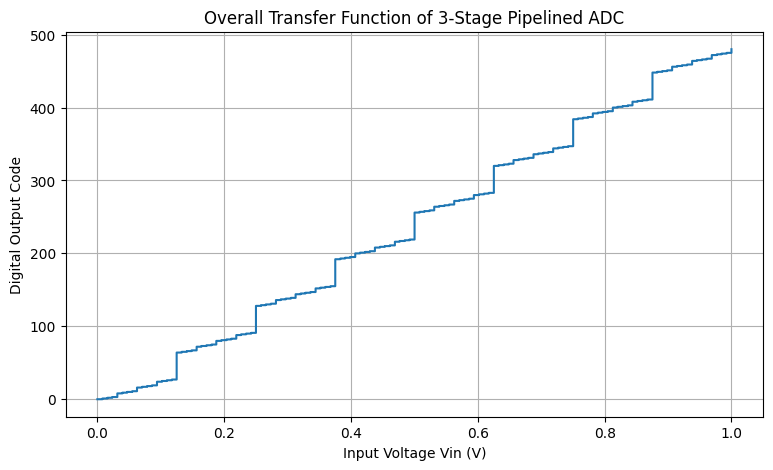

In [82]:
plt.figure(figsize=(9, 5))
plt.step(vin, digital_out, where='post', linewidth=1.5)
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('Digital Output Code')
plt.title('Overall Transfer Function of 3-Stage Pipelined ADC')
plt.grid(True)
plt.show()

Part C

In [84]:
def compute_psd_sndr_enob(signal, Fs):
    signal = signal - np.mean(signal)
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2
    freqs = np.fft.rfftfreq(N, d=1/Fs)

    psd_db = 10 * np.log10(power / np.max(power) + 1e-20)

    # Ignore DC, locate fundamental
    fundamental_bin = np.argmax(power[1:]) + 1
    signal_power = power[fundamental_bin]
    noise_dist_power = np.sum(power[1:]) - signal_power

    sndr = 10 * np.log10(signal_power / (noise_dist_power + 1e-20))
    enob = (sndr - 1.76) / 6.02

    return freqs, psd_db, fundamental_bin, sndr, enob

In [85]:
# Sampling setup
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13  # coherent input tone

# Single-tone input with amplitude VFS
# To keep the waveform centered in the 0-to-VFS ADC input range:
vin = 0.5 * VFS + 0.5 * VFS * np.sin(2 * np.pi * fin * n / Fs)

# Run pipelined ADC
result = pipelined_adc_3stage_nonideal(
    vin,
    stage1_subadc=zero_subadc,
    stage2_subadc=zero_subadc,
    stage3_subadc=zero_subadc,
    stage1_ra=zero_ra,
    stage2_ra=zero_ra,
    stage3_ra=zero_ra,
    VFS=VFS,
    gain=G,
    refs=refs
)

adc_out = result["digital_out"]

# Compute PSD, SNDR, ENOB
freqs, psd_db, fundamental_bin, sndr, enob = compute_psd_sndr_enob(adc_out, Fs)

print(f"Fundamental bin = {fundamental_bin}")
print(f"SNDR = {sndr:.2f} dB")
print(f"ENOB = {enob:.2f} bits")

Fundamental bin = 13
SNDR = 25.31 dB
ENOB = 3.91 bits


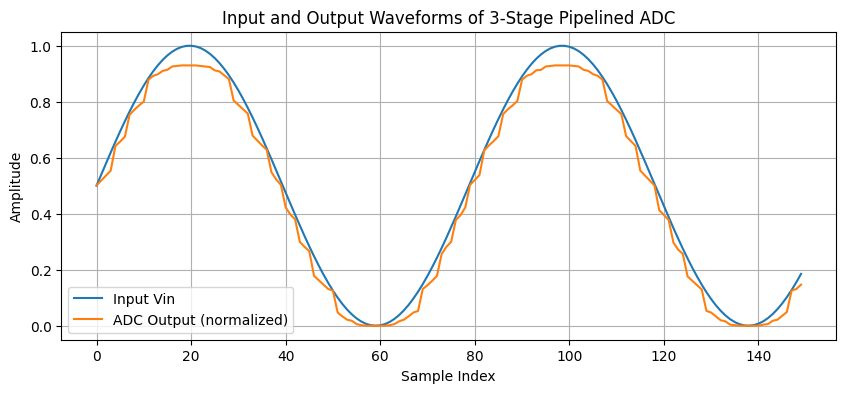

In [86]:
# Plot input and output waveforms
plt.figure(figsize=(10, 4))
plt.plot(n[:150], vin[:150], label='Input Vin', linewidth=1.5)
plt.plot(n[:150], adc_out[:150] / 511.0, label='ADC Output (normalized)', linewidth=1.5)
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Input and Output Waveforms of 3-Stage Pipelined ADC')
plt.grid(True)
plt.legend()
plt.show()

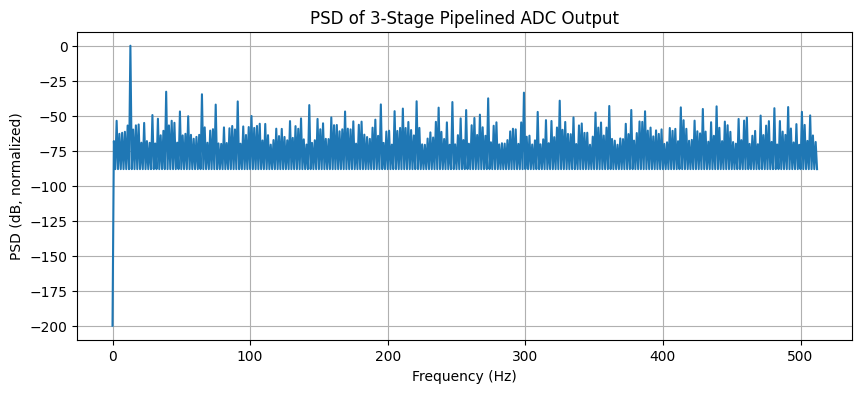

In [87]:
# Plot PSD
plt.figure(figsize=(10, 4))
plt.plot(freqs, psd_db, linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB, normalized)')
plt.title('PSD of 3-Stage Pipelined ADC Output')
plt.grid(True)
plt.show()

Part D

In [91]:
import copy

def compute_sndr(signal):
    signal = signal - np.mean(signal)
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    power = np.abs(spectrum)**2

    fundamental_bin = np.argmax(power[1:]) + 1
    signal_power = power[fundamental_bin]
    noise_dist_power = np.sum(power[1:]) - signal_power

    sndr = 10 * np.log10(signal_power / (noise_dist_power + 1e-20))
    return sndr

def run_sndr(stage1_subadc, stage2_subadc, stage3_subadc,
             stage1_ra, stage2_ra, stage3_ra):
    result = pipelined_adc_3stage_nonideal(
        vin,
        stage1_subadc=stage1_subadc,
        stage2_subadc=stage2_subadc,
        stage3_subadc=stage3_subadc,
        stage1_ra=stage1_ra,
        stage2_ra=stage2_ra,
        stage3_ra=stage3_ra,
        VFS=VFS,
        gain=G,
        refs=refs
    )
    adc_out = result["digital_out"]
    return compute_sndr(adc_out)

In [92]:
# Sampling Parameters
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13
vin = 0.5 * VFS + 0.5 * VFS * np.sin(2 * np.pi * fin * n / Fs)

# 1) 1st stage sub-ADC offset voltage: -0.4VFS to 0.4VFS
sweep1 = np.linspace(-0.4 * VFS, 0.4 * VFS, 25)
sndr1 = []
for val in sweep1:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    s1["vos"][:] = val
    sndr1.append(run_sndr(s1, s2, s3, r1, r2, r3))

# 2) 2nd stage sub-ADC gain error: 0 to 0.05
sweep2 = np.linspace(0, 0.05, 25)
sndr2 = []
for val in sweep2:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    s2["eps"][:] = val
    sndr2.append(run_sndr(s1, s2, s3, r1, r2, r3))

# 3) 3rd stage sub-ADC second-order nonlinearity: -0.05/VFS^2 to 0.05/VFS^2
sweep3 = np.linspace(-0.05 / (VFS**2), 0.05 / (VFS**2), 25)
sndr3 = []
for val in sweep3:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    s3["alpha2"][:] = val
    sndr3.append(run_sndr(s1, s2, s3, r1, r2, r3))

# 4) 1st stage RA gain error: 0 to 0.05
sweep4 = np.linspace(0, 0.05, 25)
sndr4 = []
for val in sweep4:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    r1["epsilon"] = val
    sndr4.append(run_sndr(s1, s2, s3, r1, r2, r3))

# 5) 2nd stage RA offset voltage: -0.4VFS to 0.4VFS
sweep5 = np.linspace(-0.4 * VFS, 0.4 * VFS, 25)
sndr5 = []
for val in sweep5:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    r2["v_offset"] = val
    sndr5.append(run_sndr(s1, s2, s3, r1, r2, r3))

# 6) 3rd stage RA third-order nonlinearity: -0.05/VFS^3 to 0.05/VFS^3
sweep6 = np.linspace(-0.05 / (VFS**3), 0.05 / (VFS**3), 25)
sndr6 = []
for val in sweep6:
    s1 = copy.deepcopy(zero_subadc)
    s2 = copy.deepcopy(zero_subadc)
    s3 = copy.deepcopy(zero_subadc)
    r1 = copy.deepcopy(zero_ra)
    r2 = copy.deepcopy(zero_ra)
    r3 = copy.deepcopy(zero_ra)

    r3["alpha3"] = val
    sndr6.append(run_sndr(s1, s2, s3, r1, r2, r3))

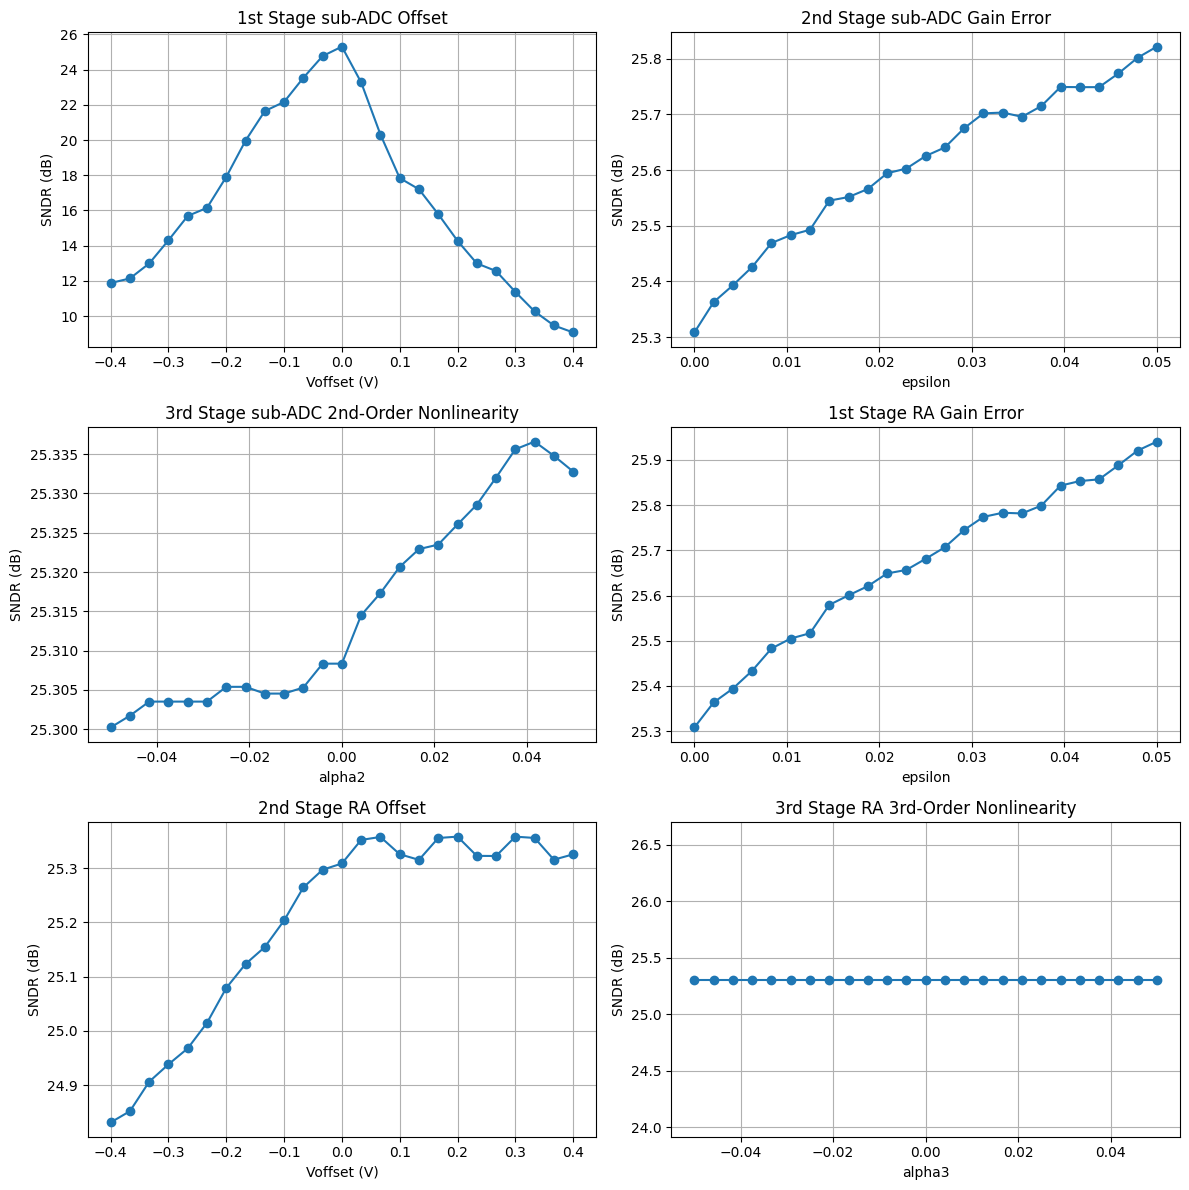

In [94]:
# Plotting the sweeps
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.ravel()

axs[0].plot(sweep1, sndr1, marker='o')
axs[0].set_title('1st Stage sub-ADC Offset')
axs[0].set_xlabel('Voffset (V)')
axs[0].set_ylabel('SNDR (dB)')
axs[0].grid(True)

axs[1].plot(sweep2, sndr2, marker='o')
axs[1].set_title('2nd Stage sub-ADC Gain Error')
axs[1].set_xlabel('epsilon')
axs[1].set_ylabel('SNDR (dB)')
axs[1].grid(True)

axs[2].plot(sweep3, sndr3, marker='o')
axs[2].set_title('3rd Stage sub-ADC 2nd-Order Nonlinearity')
axs[2].set_xlabel('alpha2')
axs[2].set_ylabel('SNDR (dB)')
axs[2].grid(True)

axs[3].plot(sweep4, sndr4, marker='o')
axs[3].set_title('1st Stage RA Gain Error')
axs[3].set_xlabel('epsilon')
axs[3].set_ylabel('SNDR (dB)')
axs[3].grid(True)

axs[4].plot(sweep5, sndr5, marker='o')
axs[4].set_title('2nd Stage RA Offset')
axs[4].set_xlabel('Voffset (V)')
axs[4].set_ylabel('SNDR (dB)')
axs[4].grid(True)

axs[5].plot(sweep6, sndr6, marker='o')
axs[5].set_title('3rd Stage RA 3rd-Order Nonlinearity')
axs[5].set_xlabel('alpha3')
axs[5].set_ylabel('SNDR (dB)')
axs[5].grid(True)

plt.tight_layout()
plt.show()

Part E

In [96]:
def pipelined_adc_3stage_redundant(vin, stage1_subadc, stage2_subadc, stage3_subadc, stage1_ra, stage2_ra, stage3_ra, VFS=1.0, gain=4, refs=None):
    vin = np.atleast_1d(vin)

    if refs is None:
        refs = np.arange(1, 8) * VFS / 8

    # Reuse the same non-ideal analog pipeline
    result = pipelined_adc_3stage_nonideal(
        vin,
        stage1_subadc=stage1_subadc,
        stage2_subadc=stage2_subadc,
        stage3_subadc=stage3_subadc,
        stage1_ra=stage1_ra,
        stage2_ra=stage2_ra,
        stage3_ra=stage3_ra,
        VFS=VFS,
        gain=gain,
        refs=refs
    )

    # Effective 2-bit contribution per stage (behavioral redundancy model)
    c1_eff = result["stage1"]["dec_code"] >> 1
    c2_eff = result["stage2"]["dec_code"] >> 1
    c3_eff = result["stage3"]["dec_code"] >> 1

    digital_out_red = (c1_eff << 4) + (c2_eff << 2) + c3_eff

    result["digital_out_redundant"] = digital_out_red
    return result

def run_sndr_pipeline(stage1_subadc, stage2_subadc, stage3_subadc,
                      stage1_ra, stage2_ra, stage3_ra,
                      redundant=False):
    if redundant:
        result = pipelined_adc_3stage_redundant(
            vin,
            stage1_subadc=stage1_subadc,
            stage2_subadc=stage2_subadc,
            stage3_subadc=stage3_subadc,
            stage1_ra=stage1_ra,
            stage2_ra=stage2_ra,
            stage3_ra=stage3_ra,
            VFS=VFS,
            gain=G,
            refs=refs
        )
        adc_out = result["digital_out_redundant"]
    else:
        result = pipelined_adc_3stage_nonideal(
            vin,
            stage1_subadc=stage1_subadc,
            stage2_subadc=stage2_subadc,
            stage3_subadc=stage3_subadc,
            stage1_ra=stage1_ra,
            stage2_ra=stage2_ra,
            stage3_ra=stage3_ra,
            VFS=VFS,
            gain=G,
            refs=refs
        )
        adc_out = result["digital_out"]

    return compute_sndr(adc_out)

In [97]:
# Input tone from 4c/4d
Fs = 1024
N = 1024
n = np.arange(N)
fin = 13
vin = 0.5 * VFS + 0.5 * VFS * np.sin(2 * np.pi * fin * n / Fs)

def sweep_case(param_values, modify_fn):
    sndr_red = []
    sndr_nored = []

    for val in param_values:
        s1 = copy.deepcopy(zero_subadc)
        s2 = copy.deepcopy(zero_subadc)
        s3 = copy.deepcopy(zero_subadc)
        r1 = copy.deepcopy(zero_ra)
        r2 = copy.deepcopy(zero_ra)
        r3 = copy.deepcopy(zero_ra)

        modify_fn(val, s1, s2, s3, r1, r2, r3)

        sndr_red.append(run_sndr_pipeline(s1, s2, s3, r1, r2, r3, redundant=True))
        sndr_nored.append(run_sndr_pipeline(s1, s2, s3, r1, r2, r3, redundant=False))

    return np.array(sndr_red), np.array(sndr_nored)

# 1) 1st stage sub-ADC offset
x1 = np.linspace(-0.4 * VFS, 0.4 * VFS, 25)
y1_red, y1_nored = sweep_case(x1, lambda val, s1, s2, s3, r1, r2, r3: s1["vos"].fill(val))

# 2) 2nd stage sub-ADC gain error
x2 = np.linspace(0, 0.05, 25)
y2_red, y2_nored = sweep_case(x2, lambda val, s1, s2, s3, r1, r2, r3: s2["eps"].fill(val))

# 3) 3rd stage sub-ADC alpha2
x3 = np.linspace(-0.05 / (VFS**2), 0.05 / (VFS**2), 25)
y3_red, y3_nored = sweep_case(x3, lambda val, s1, s2, s3, r1, r2, r3: s3["alpha2"].fill(val))

# 4) 1st stage RA epsilon
x4 = np.linspace(0, 0.05, 25)
y4_red, y4_nored = sweep_case(x4, lambda val, s1, s2, s3, r1, r2, r3: r1.update({"epsilon": val}))

# 5) 2nd stage RA offset
x5 = np.linspace(-0.4 * VFS, 0.4 * VFS, 25)
y5_red, y5_nored = sweep_case(x5, lambda val, s1, s2, s3, r1, r2, r3: r2.update({"v_offset": val}))

# 6) 3rd stage RA alpha3
x6 = np.linspace(-0.05 / (VFS**3), 0.05 / (VFS**3), 25)
y6_red, y6_nored = sweep_case(x6, lambda val, s1, s2, s3, r1, r2, r3: r3.update({"alpha3": val}))

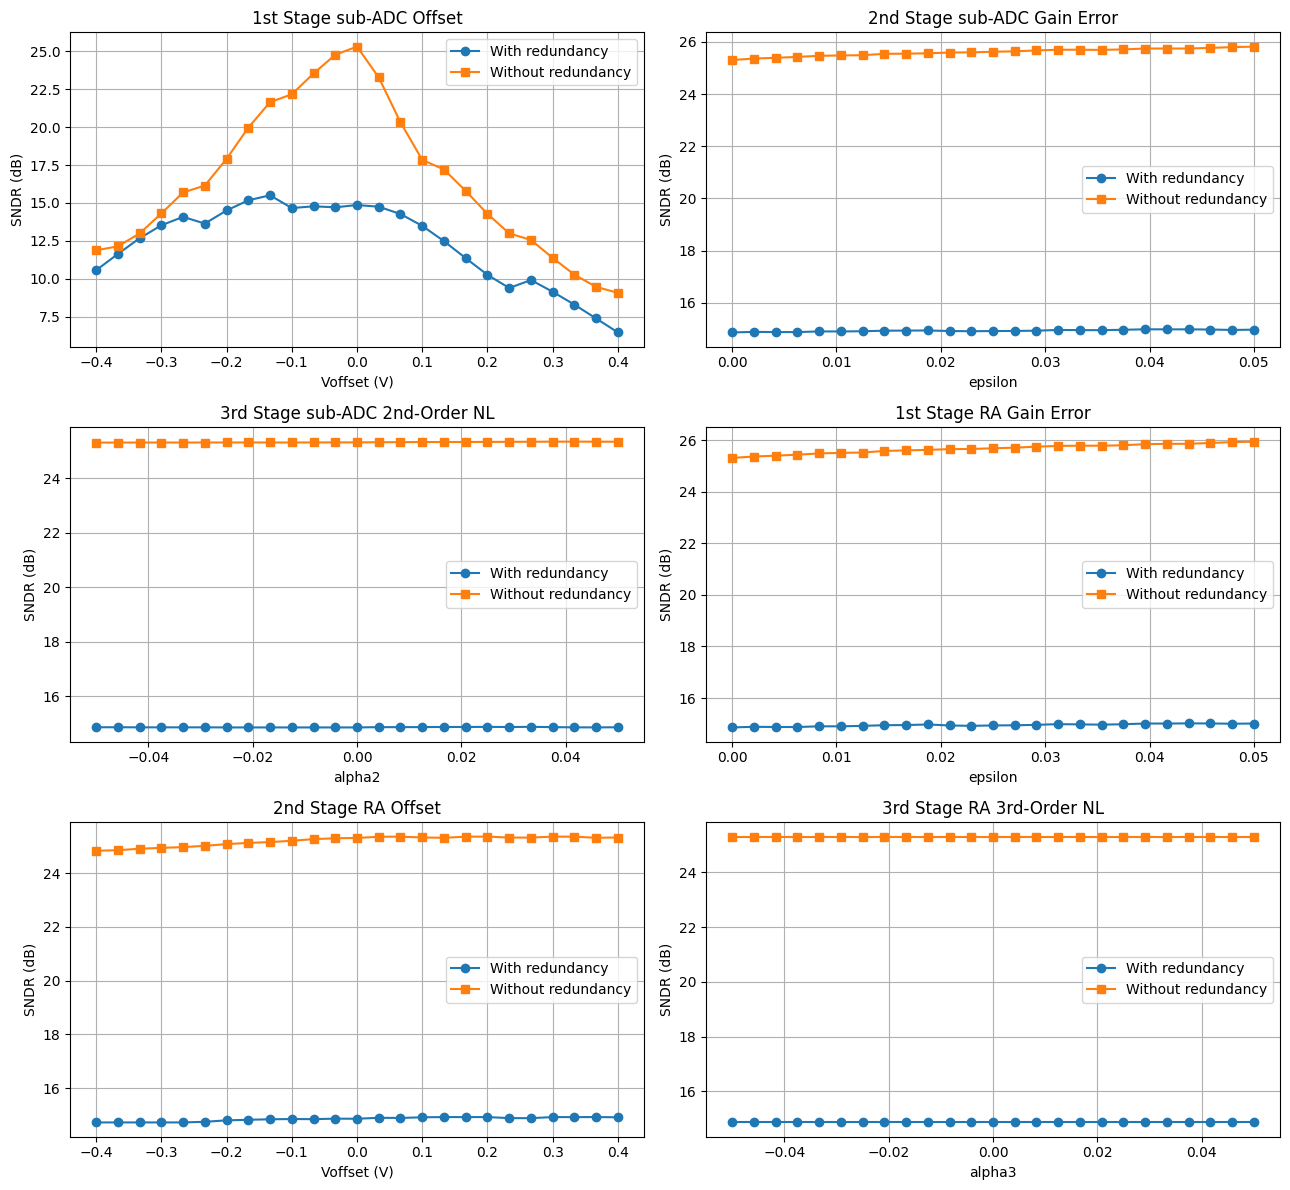

In [98]:
fig, axs = plt.subplots(3, 2, figsize=(13, 12))
axs = axs.ravel()

plots = [
    (x1, y1_red, y1_nored, '1st Stage sub-ADC Offset', 'Voffset (V)'),
    (x2, y2_red, y2_nored, '2nd Stage sub-ADC Gain Error', 'epsilon'),
    (x3, y3_red, y3_nored, '3rd Stage sub-ADC 2nd-Order NL', 'alpha2'),
    (x4, y4_red, y4_nored, '1st Stage RA Gain Error', 'epsilon'),
    (x5, y5_red, y5_nored, '2nd Stage RA Offset', 'Voffset (V)'),
    (x6, y6_red, y6_nored, '3rd Stage RA 3rd-Order NL', 'alpha3')
]

for ax, (x, yred, ynored, title, xlabel) in zip(axs, plots):
    ax.plot(x, yred, marker='o', label='With redundancy')
    ax.plot(x, ynored, marker='s', label='Without redundancy')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('SNDR (dB)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

All non-idealities have been mitigated by having redundancy in the three stage ADC.

Part F

SNDR maximization for this three stage pipelined ADC is a non-convex problem. While certain non-idealitites show a linear relationship with SNDR, looking at all the non-idealitites collectively show a highly non-linear relationhsip to SNDR. From the analysis done in the previous part, we can see that there isn't a very linear trend for some of the parameters being swept.

Vin

 │

 ▼

[ Stage 1 Sub-ADC ] --offset/gain/nonlinearity--> [ Digital correction / calibration ]

 │

 ▼

[ Stage 1 MDAC + RA ] --gain/offset/nonlinearity--> [ Calibration coefficients update ]

 │

 ▼

[ Stage 2 Sub-ADC ] --offset/gain/nonlinearity--> [ Digital correction / calibration ]

 │

 ▼

[ Stage 2 MDAC + RA ] --gain/offset/nonlinearity--> [ Calibration coefficients update ]

 │

 ▼

[ Stage 3 Sub-ADC ] --offset/gain/nonlinearity--> [ Digital correction / calibration ]

 │

 ▼

Digital output ---> SNDR/INL/DNL cost function ---> coefficient adaptation